In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Sample data.csv")

df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,01-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,01-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,01-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,01-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,01-Jun-14,6,June,2014


In [3]:
df.shape

(700, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        647 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9    Sales               700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

In [5]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,7.900000,2013.750000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,3.377321,0.433322
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,12.000000,2014.000000


In [6]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,53
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [8]:
df.columns = df.columns.str.strip()

df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,53
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [14]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [16]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

/tmp/ipykernel_2068/3693147909.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [17]:
df["Date"].head()

,Date
0,2014-12-01
1,2014-06-01
2,2013-11-01
3,2014-12-01
4,2014-06-01


In [18]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

In [19]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

In [20]:
df["Discount_Percentage"] = (df["Discounts"] / df["Gross Sales"]) * 100

In [21]:
df["Revenue_Per_Unit"] = df["Sales"] / df["Units Sold"]

In [22]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,...,Profit,Date,Month Number,Month Name,Year,Month,Month_Name,Profit_Margin,Discount_Percentage,Revenue_Per_Unit
0,Government,Germany,Carretera,High,1513.0,3,350,529550.0,0.0,529550.0,...,136170.0,2014-12-01,12,December,2014,12,December,25.714286,0.0,350.0
1,Government,Germany,Paseo,High,1006.0,10,350,352100.0,0.0,352100.0,...,90540.0,2014-06-01,6,June,2014,6,June,25.714286,0.0,350.0
2,Government,Canada,Paseo,High,1725.0,10,350,603750.0,0.0,603750.0,...,155250.0,2013-11-01,11,November,2013,11,November,25.714286,0.0,350.0
3,Government,Germany,Paseo,High,1513.0,10,350,529550.0,0.0,529550.0,...,136170.0,2014-12-01,12,December,2014,12,December,25.714286,0.0,350.0
4,Government,Germany,Velo,High,1006.0,120,350,352100.0,0.0,352100.0,...,90540.0,2014-06-01,6,June,2014,6,June,25.714286,0.0,350.0


In [23]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_units = df["Units Sold"].sum()
total_gross_sales = df["Gross Sales"].sum()
total_discounts = df["Discounts"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units)
print("Total Gross Sales:", total_gross_sales)
print("Total Discounts:", total_discounts)

Total Sales: 118726350.25999999
Total Profit: 16893702.26
Total Units Sold: 1125806.0
Total Gross Sales: 127931598.5
Total Discounts: 9205248.239999998


In [24]:
overall_profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", overall_profit_margin)

Overall Profit Margin: 14.229109395685388


In [25]:
sales_by_country = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_country

,Sales
Country,
United States of America,2.502983e+07
Canada,2.488765e+07
France,2.435417e+07
Germany,2.350534e+07
Mexico,2.094935e+07


In [26]:
profit_by_country = (
    df.groupby("Country")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_country

,Profit
Country,
France,3781020.780
Germany,3680388.820
Canada,3529228.885
United States of America,2995540.665
Mexico,2907523.110


In [27]:
sales_by_product = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_product

,Sales
Product,
Paseo,3.301114e+07
VTT,2.051192e+07
Velo,1.825006e+07
Amarilla,1.774712e+07
Montana,1.539080e+07
Carretera,1.381531e+07


In [28]:
profit_by_product = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_product

,Profit
Product,
Paseo,4797437.950
VTT,3034608.020
Amarilla,2814104.060
Velo,2305992.465
Montana,2114754.880
Carretera,1826804.885


In [29]:
sales_by_segment = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

,Sales
Segment,
Government,5.250426e+07
Small Business,4.242792e+07
Enterprise,1.961169e+07
Midmarket,2.381883e+06
Channel Partners,1.800594e+06


In [30]:
profit_by_segment = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_segment

,Profit
Segment,
Government,1.138817e+07
Small Business,4.143168e+06
Channel Partners,1.316803e+06
Midmarket,6.601031e+05
Enterprise,-6.145456e+05


In [31]:
yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales

,Sales
Year,
2013,26415255.51
2014,92311094.75


In [32]:
yearly_profit = df.groupby("Year")["Profit"].sum()

yearly_profit

,Profit
Year,
2013,3878464.51
2014,13015237.75


In [33]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2013,9,4484000.03
1,2013,10,9295611.10
2,2013,11,7267203.30
3,2013,12,5368441.08
4,2014,1,6607761.68


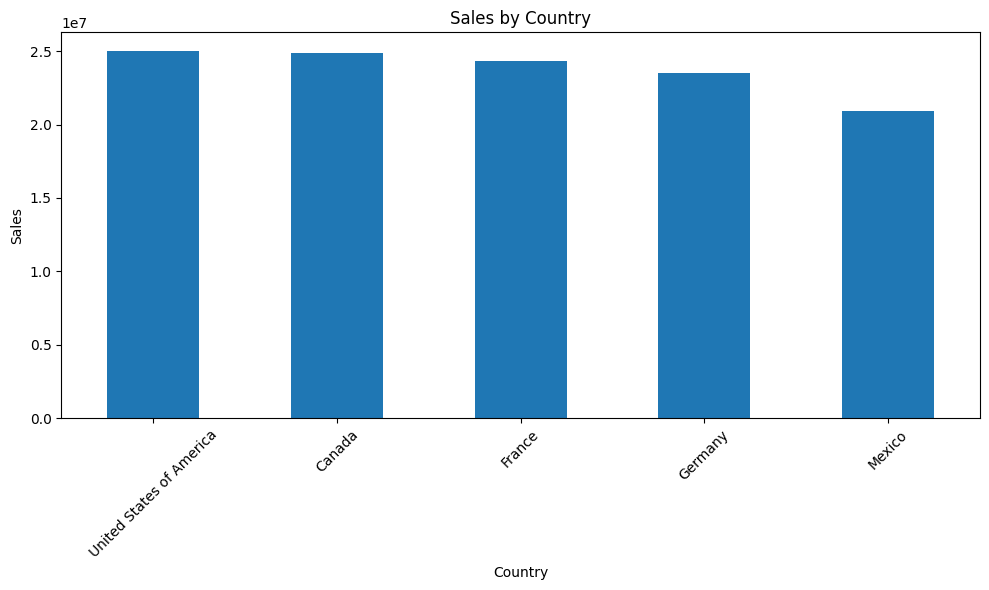

In [34]:
plt.figure(figsize=(10,6))

sales_by_country.plot(kind="bar")

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

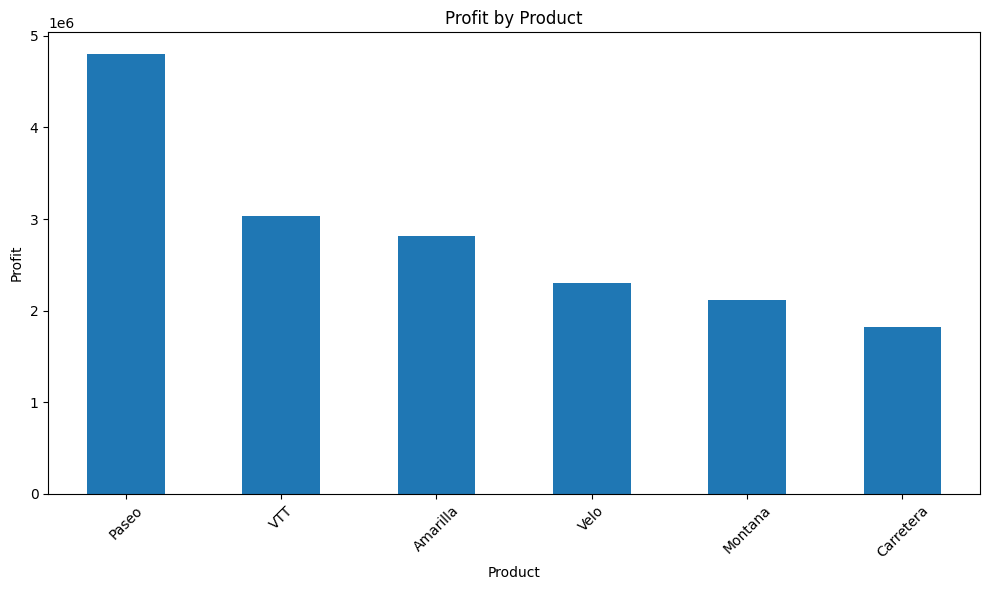

In [35]:
plt.figure(figsize=(10,6))

profit_by_product.plot(kind="bar")

plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

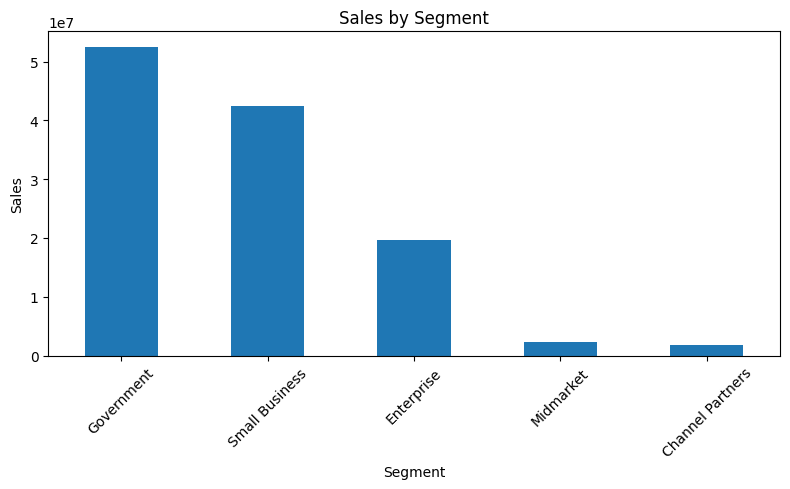

In [36]:
plt.figure(figsize=(8,5))

sales_by_segment.plot(kind="bar")

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

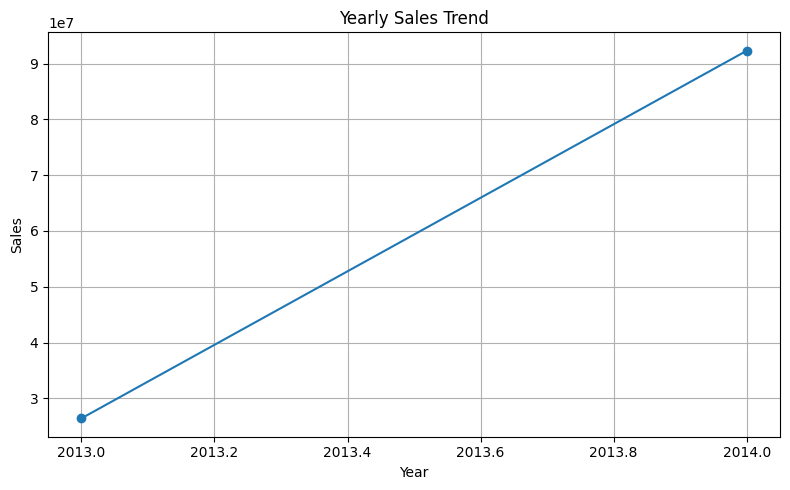

In [37]:
plt.figure(figsize=(8,5))

yearly_sales.plot(kind="line", marker="o")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()

plt.show()

In [38]:
df.to_csv(
    "cleaned_sales_data.csv",
    index=False
)